### 4-1. 인구현황 데이터 분석

1. 지역별 총인구수 Top5


,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


1-1. 지역별 총인구수 plot


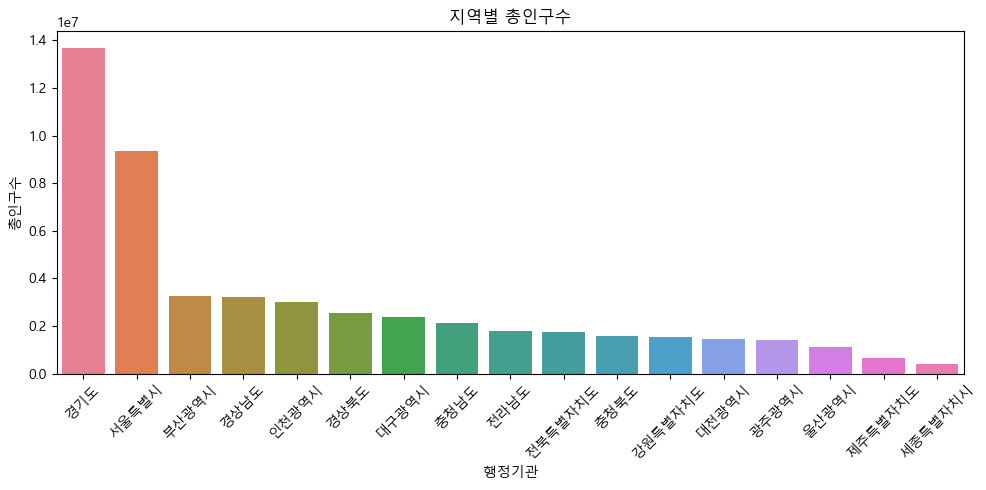

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rc('font', family='Malgun Gothic') # Mac의 경우 'AppleGothic'
plt.rc('axes', unicode_minus=False)


df = pd.read_csv('data/인구현황.csv')
df = df[df['행정기관'] != '전국']

# 1) Top 5
top5_pop = df.sort_values(by='총인구수', ascending=False)[['행정기관', '총인구수']].head(5)
print("1. 지역별 총인구수 Top5")
display(top5_pop)

# 1-1) Plot
print("1-1. 지역별 총인구수 plot")
plt.figure(figsize=(10, 5))
df_sorted_pop = df.sort_values(by='총인구수', ascending=False)
sns.barplot(data=df_sorted_pop, x='행정기관', y='총인구수', hue='행정기관', legend=False)
plt.title('지역별 총인구수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. 세대당 인구수 높은 지역 Top5


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


2-1. 지역별 세대당 인구 Plot


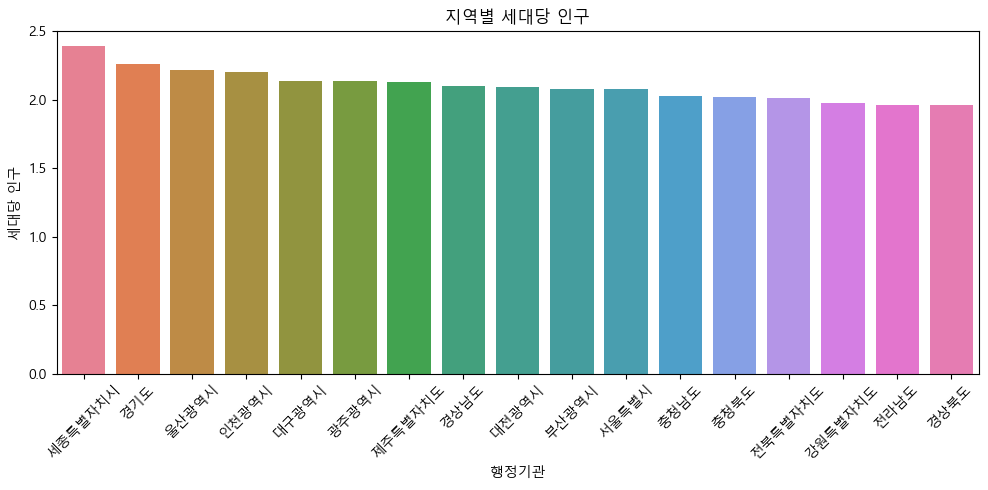

In [7]:
# 2) Top 5
top5_household = df.sort_values(by='세대당 인구', ascending=False)[['행정기관', '세대당 인구']].head(5).reset_index(drop=True)
print("2. 세대당 인구수 높은 지역 Top5")
display(top5_household)

# 2-1) Plot
plt.figure(figsize=(10, 5))
df_sorted_hh = df.sort_values(by='세대당 인구', ascending=False)
print('2-1. 지역별 세대당 인구 Plot')
sns.barplot(data=df_sorted_hh, x='행정기관', y='세대당 인구', hue='행정기관', legend=False)
plt.title('지역별 세대당 인구')
plt.xticks(rotation=45)
plt.ylim(0, 2.5)
plt.tight_layout()
plt.show()

3. 남녀 비율 분석


,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


3-1. 남녀 비율 분석 Plot


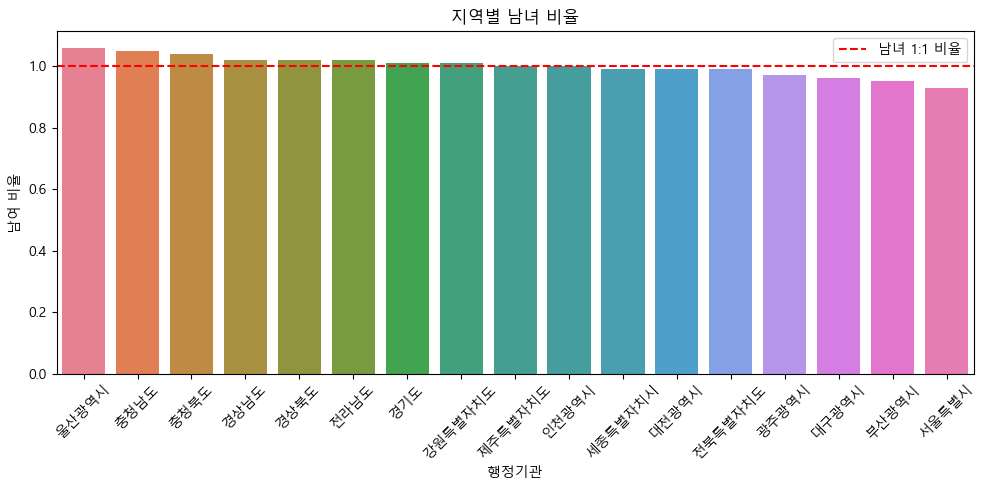

In [9]:

# 3) 남녀 비율 순 정렬
df_gender = df.sort_values(by='남여 비율', ascending=False)[['행정기관', '남여 비율']].reset_index(drop=True)
print("3. 남녀 비율 분석")
display(df_gender)

# 3-1) Plot (axhline 사용)
print('3-1. 남녀 비율 분석 Plot')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_gender, x='행정기관', y='남여 비율', hue='행정기관', legend=False)
plt.axhline(y=1.0, color='r', linestyle='--', label='남녀 1:1 비율') # 기준선 추가
plt.title('지역별 남녀 비율')
plt.ylabel('남여 비율')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [3]:
def get_gender_status(ratio):
    if ratio > 1.00:
        return '남초'
    elif ratio < 1.00:
        return '여초'
    else:
        return '동일'

# '남초여초' 컬럼 생성
df['남초여초'] = df['남여 비율'].apply(get_gender_status)

print("4. 남자초과 / 여자초과 분석")
display(df[['행정기관', '남여 비율', '남초여초']])

4. 남자초과 / 여자초과 분석


,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


전국 평균 세대당 인구수: 2.11

5. 세대당 인구 평균보다 높은 지역


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


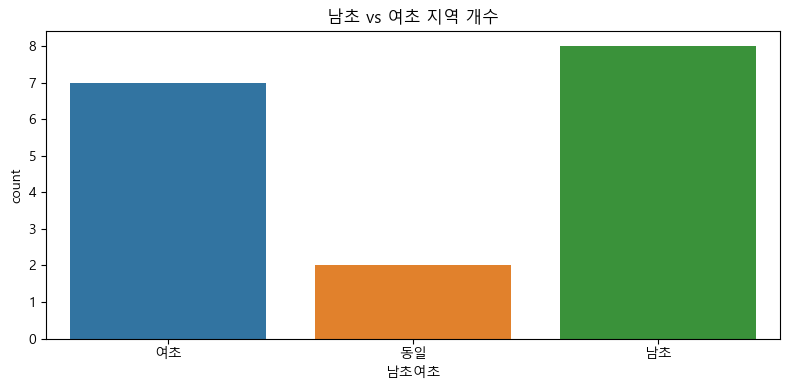

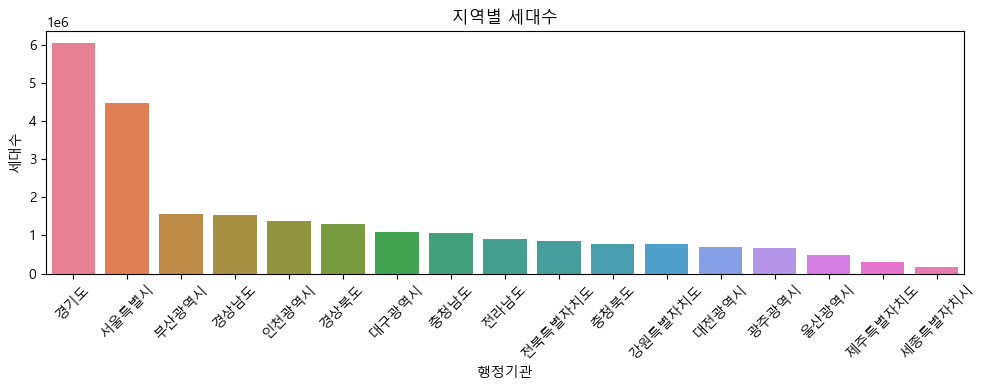

In [13]:
avg_hh_pop = df['세대당 인구'].mean() # 또는 지정된 평균값 (예: 2.11)
print(f"전국 평균 세대당 인구수: {avg_hh_pop:.2f}\n")

# 5) 평균보다 높은 지역
above_avg_hh = df[df['세대당 인구'] > avg_hh_pop][['행정기관', '세대당 인구']].sort_values(by='세대당 인구', ascending=False).reset_index(drop=True)
print("5. 세대당 인구 평균보다 높은 지역")
display(above_avg_hh)

# 5-1) 남초 vs 여초 개수 Plot (countplot)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='남초여초', hue='남초여초', order=['여초', '동일', '남초'], legend=False)
plt.title('남초 vs 여초 지역 개수')
plt.tight_layout()
plt.show()

# 5-1) 지역별 세대수 Plot (barplot)
plt.figure(figsize=(10, 4))
df_sorted_hh_count = df.sort_values(by='세대수', ascending=False)
sns.barplot(data=df_sorted_hh_count, x='행정기관', y='세대수', hue='행정기관', legend=False)
plt.title('지역별 세대수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()